In [2]:
import numpy as np
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import copy

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import helper as h

%load_ext autoreload
%autoreload 2


In [3]:
# Weighted adjacency matrix
# K = np.array([
#     [0,   0.8, 0.4, 0  ],
#     [0.8, 0,   1.0, 0.2],
#     [0.4, 1.0, 0,   0.7],
#     [0,   0.2, 0.7, 0  ]
# ])
W = np.array([[0, 1, 1, 0], 
              [1, 0, 1, 1], 
              [1, 1, 0, 1], 
              [0, 1, 1, 0], 
])

target_edge_nodes = (1,2)
source = 0
sink = 3


# # make W for network with nodes 1-6, connections: 0-2,0-3,1-3,1-4,2-3,3-4,2-5,3-5,3-6,4-6,5-6
# W = np.array([[0, 1, 1, 1, 0, 0, 0], 
#               [1, 0, 0, 1, 1, 0, 0], 
#               [1, 0, 0, 1, 0, 1, 0], 
#               [1, 1, 1, 0, 1, 1, 1], 
#               [0, 1, 0, 1, 0, 0, 1], 
#               [0, 0, 1, 1, 0, 0, 1], 
#               [0, 0, 0, 1, 1, 1, 0],
# ])
# target_edge_nodes = (5, 6)


# Build weighted graph
G = nx.from_numpy_array(W)

# Incidence matrix B (edges x nodes)
B = - nx.incidence_matrix(G, oriented=True).toarray()
print("Incidence matrix B:\n", B)

# Diagonal matrix of conductances
edges = list(G.edges())
K = np.diag([G[u][v]['weight'] for u, v in edges])
print("Diagonal conductance matrix K:\n", K)

# Weighted Laplacian (D is now sum of weights per node)
L_weighted = nx.laplacian_matrix(G).toarray()
L_pinv = np.linalg.pinv(L_weighted)

print("Weighted Laplacian L:\n", L_weighted)


Incidence matrix B:
 [[ 1.  1. -0. -0. -0.]
 [-1. -0.  1.  1. -0.]
 [-0. -1. -1. -0.  1.]
 [-0. -0. -0. -1. -1.]]
Diagonal conductance matrix K:
 [[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]
Weighted Laplacian L:
 [[ 2 -1 -1  0]
 [-1  3 -1 -1]
 [-1 -1  3 -1]
 [ 0 -1 -1  2]]


### Graph Laplacian
Defined as $L=D-A$, D the diagonal, weighted, matrix summing the weighets of all edges entering node i $D_{ii}=\sum _j k_{ij}$
The Laplacian of the graph seatisfies, per node, 
$L \cdot \vec{p} = -\vec{Q}_{ext}$.

That is since $( L \cdot \vec{p})_i = \sum _j k_{ij} (p_i -p_j) = - \sum _j Q_{ij} = - Q_{i,ext}$, describing flow conservation at the node $i$.

The minus sign comes from defining the current sign w.r.t. to pressure difference as $Q_{ij}=k_{ij}(p_j-p_i)=-k_{ij}.(p_i-p_j)$


Edge conductances: [1, 1, 1, 1, 1]
Current injections Q_in: [ 1.  0.  0. -1.]


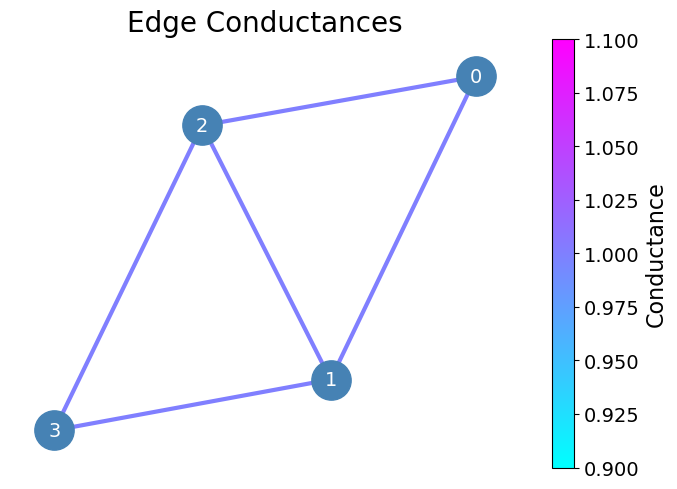

In [4]:
# Draw with edge weights
pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, 'weight')

conductance = [G[u][v]['weight'] for u, v in G.edges()]
print("Edge conductances:", conductance)
# Set source and sink, imposed currents

Qin = np.zeros(L_weighted.shape[0])
Qin[source] = 1
Qin[sink] = -1     
print("Current injections Q_in:", Qin)

# Visualize conductances
h.plot_edge_property(G, pos, conductance, title='Edge Conductances', label='Conductance')


### Pseudo inverse of L
The system is Gauge invarient for the base pressure, meaning if $\bold{p}$ is a solution $L\bold {p}=\bold{Q}_{in}$, then $\bold{p} + q\bold{1}$ for scalar $q$, is also a solution. For the case of no external currents, the pressures should be $\bold{p}=\bold{0}$, but that yields that $\bold{1}=(1,1,..,1)^T$ is also a solution $L\bold{1}=\bold{0}$. Therefore, $\bold{1}$ is in the null space of $L$, so it is singular. 

$\Delta k_{ij} = -\alpha \frac{d L}{dk_{ij}}$

In [5]:


# solve for pressures using pseudoinverse of Laplacian
p = L_pinv @ Qin
p=p - p.min()  # Shift so min pressure is 0.

print("Pressures p (pseudoinverse):", np.round(p, 4))



Pressures p (pseudoinverse): [1.  0.5 0.5 0. ]


(5, 5) (5, 4) (4,)
Flows Q: [0.5 0.5 0.  0.5 0.5]


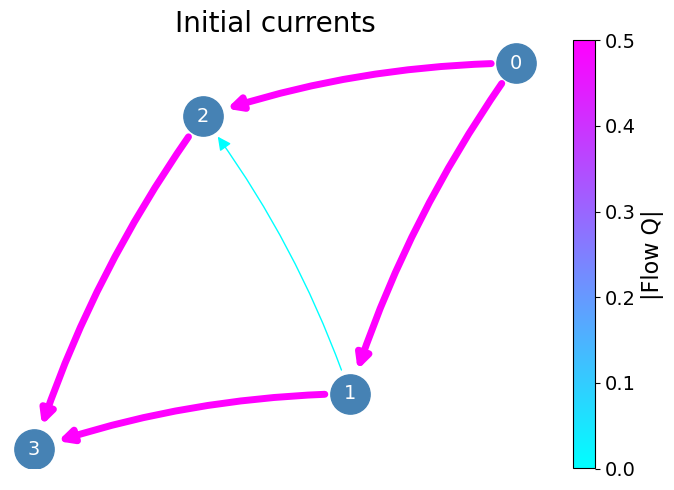

In [6]:
# now that the pressures are known, compute the flows on each edge as Q_ij = K_ij * (p_i - p_j)
print(np.shape(K), np.shape(B.T), np.shape(p))

Q = K @ B.T @ p
print("Flows Q:", np.round(Q, 4))
# Visualize currents

h.plot_edge_property(G, pos, Q, title='Initial currents', label='Flow Q', signed=True)


In [7]:
print("Edges:", list(G.edges()))
print("B.T:\n", B.T)
print("Pressures p:", p)
print("Flows I:", np.round(Q, 4))
print(K @ B.T)
print(Q)

Edges: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)]
B.T:
 [[ 1. -1. -0. -0.]
 [ 1. -0. -1. -0.]
 [-0.  1. -1. -0.]
 [-0.  1. -0. -1.]
 [-0. -0.  1. -1.]]
Pressures p: [1.  0.5 0.5 0. ]
Flows I: [0.5 0.5 0.  0.5 0.5]
[[ 1. -1.  0.  0.]
 [ 1.  0. -1.  0.]
 [ 0.  1. -1.  0.]
 [ 0.  1.  0. -1.]
 [ 0.  0.  1. -1.]]
[5.00000000e-01 5.00000000e-01 1.11022302e-16 5.00000000e-01
 5.00000000e-01]


In [8]:
# define learning constants
learning_rate = 0.001
loss_delta = 1e-6

# Target: we want to increase flow on edge (1,2)
# Deltaq_C encodes the "nudge" toward the target
# target_edge_nodes = (1, 2)
target_current = 0.1  # desired flow on that edge
target_edge_idx = edges.index(target_edge_nodes)

Qin = np.zeros(L_weighted.shape[0])
Qin[source] = 1
Qin[sink] = -1     

G_init = copy.deepcopy(G)  # save initial state
G_current = copy.deepcopy(G)  # working copy for optimization

K, L_pinv = get_graph_conductances_and_inverse_laplacian(G_current)

NameError: name 'get_graph_conductances_and_inverse_laplacian' is not defined

In [ ]:


# before optimization loop, compute the initial flow on the target edge
p = L_pinv @ Qin
p = p - p.min()  # Shift so min pressure is 0

q_F = K @ B.T @ p

loss = h.loss_function(q_F[target_edge_idx], target_current)
print(f"Target flow on edge {target_edge_nodes}: {target_current}, current flow: {q_F[target_edge_idx]:.4f}, loss: {loss:.4f}")
print(f"original conductances: {[G[u][v]['weight'] for u, v in edges]}")

losses = [] 
history = []

ii = 0
dloss = 1
print(" === Starting optimization loop === ")
while loss > loss_delta: # and dloss > 1e-11:
# for ii in range(100000):
    # inject current accross the target edge to nudge flow in the right direction, add small current across it btween 
    Delta_Qin = learning_rate * (q_F[target_edge_idx]- target_current)
    Qin_C = Qin + Delta_Qin * (B[:, target_edge_idx])  # inject current across the target edge

    # CLAMPED CIRCUIT: solve pressures and currents, when forced to have more current on the target edge
    p_C = L_pinv @ Qin_C
    p_C = p_C - p_C.min()  # Shift so min pressure is 0
    q_C = K @ B.T @ p_C
    # print(f"Clamped flow on edge {target_edge_nodes}: {q_C[target_edge_idx]:.4f}, Delta_Q_in: {Delta_Q_in:.6f}, clamped pressures: {np.round(p_C, 4)}, free pressures: {np.round(p, 2)}")

    # ── Conductance update ─────────────────────────────────────────────
    dk = h.conductance_update_SR(q_C, q_F, K, lr=learning_rate)
    # dk = conductance_update_shear(q_C, q_F, K, lr=0.1)
    for e, (u, v) in enumerate(edges):
        G_current[u][v]['weight'] += dk[e]
        G_current[u][v]['weight'] = max(G_current[u][v]['weight'], 1e-4)  # prevent negative conductance   
    # print(f"Updated conductances: {[G[u][v]['weight'] for u, v in edges]}")

    # ── Rebuild network ────────────────────────────────────────────────
    K_curr, L_pinv_curr = h.get_graph_conductances_and_inverse_laplacian(G_current)

    # ── Free phase : solve pressures and currents with updated conductances ─────────────────────────
    p_F = L_pinv_curr @ Qin
    p_F = p_F - p_F.min()  # Shift so min pressure is 0
    q_F = K_curr @ B.T @ p_F

    # print(f"edge {i}: ({u},{v})  |  Q={q_F[i]:.5f}  |  k={G_current[u][v]['weight']:.5f}")
    old_loss = loss
    loss = h.loss_function(q_F[target_edge_idx], target_current)
    losses.append(loss)
    dloss = np.abs(loss - old_loss)

    ii += 1
    if ii % 100 == 0:
        print(f"Iteration {ii}, target flow: {target_current}, current flow: {q_F[target_edge_idx]:.5f}, loss: {loss:.6f}")
        history.append({
            'step': ii,
            'loss': loss,
            'conductances': [G_current[u][v]['weight'] for u, v in edges],
            'flows': q_F.copy(),
            'pressures': p_F.copy()
        })

print(" === Optimization loop finished === ")


NameError: name 'L_pinv' is not defined

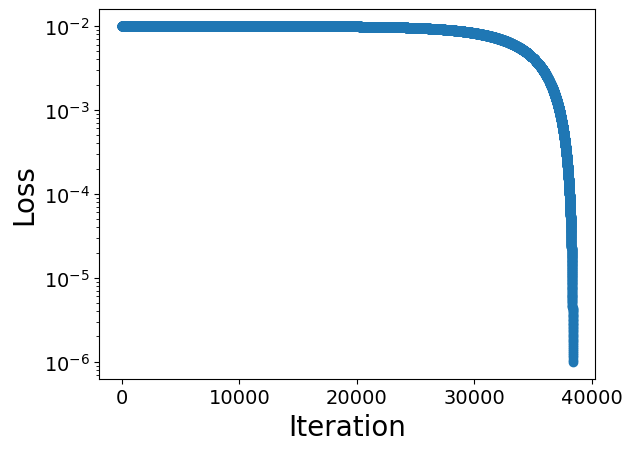

In [ ]:
# plt.scatter(range(len(losses)), np.sqrt(losses))
plt.scatter(range(len(losses)), losses)
 # loss is defined as (Q-Q_goal)**2. plot also sqrt of that
plt.yscale('log')

# plot delta loss
# nploss = np.array(losses)
# plt.scatter(range(len(losses)-1),nploss[1::]-nploss[:-1])
# plt.scatter(range(len(losses)-1),losses[1::]-losses[::-1])
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.tick_params(labelsize=14)
plt.show()



In [ ]:
h.plot_history(history, edges, target_edge_nodes, target_current)

AttributeError: module 'helper' has no attribute 'plot_history'

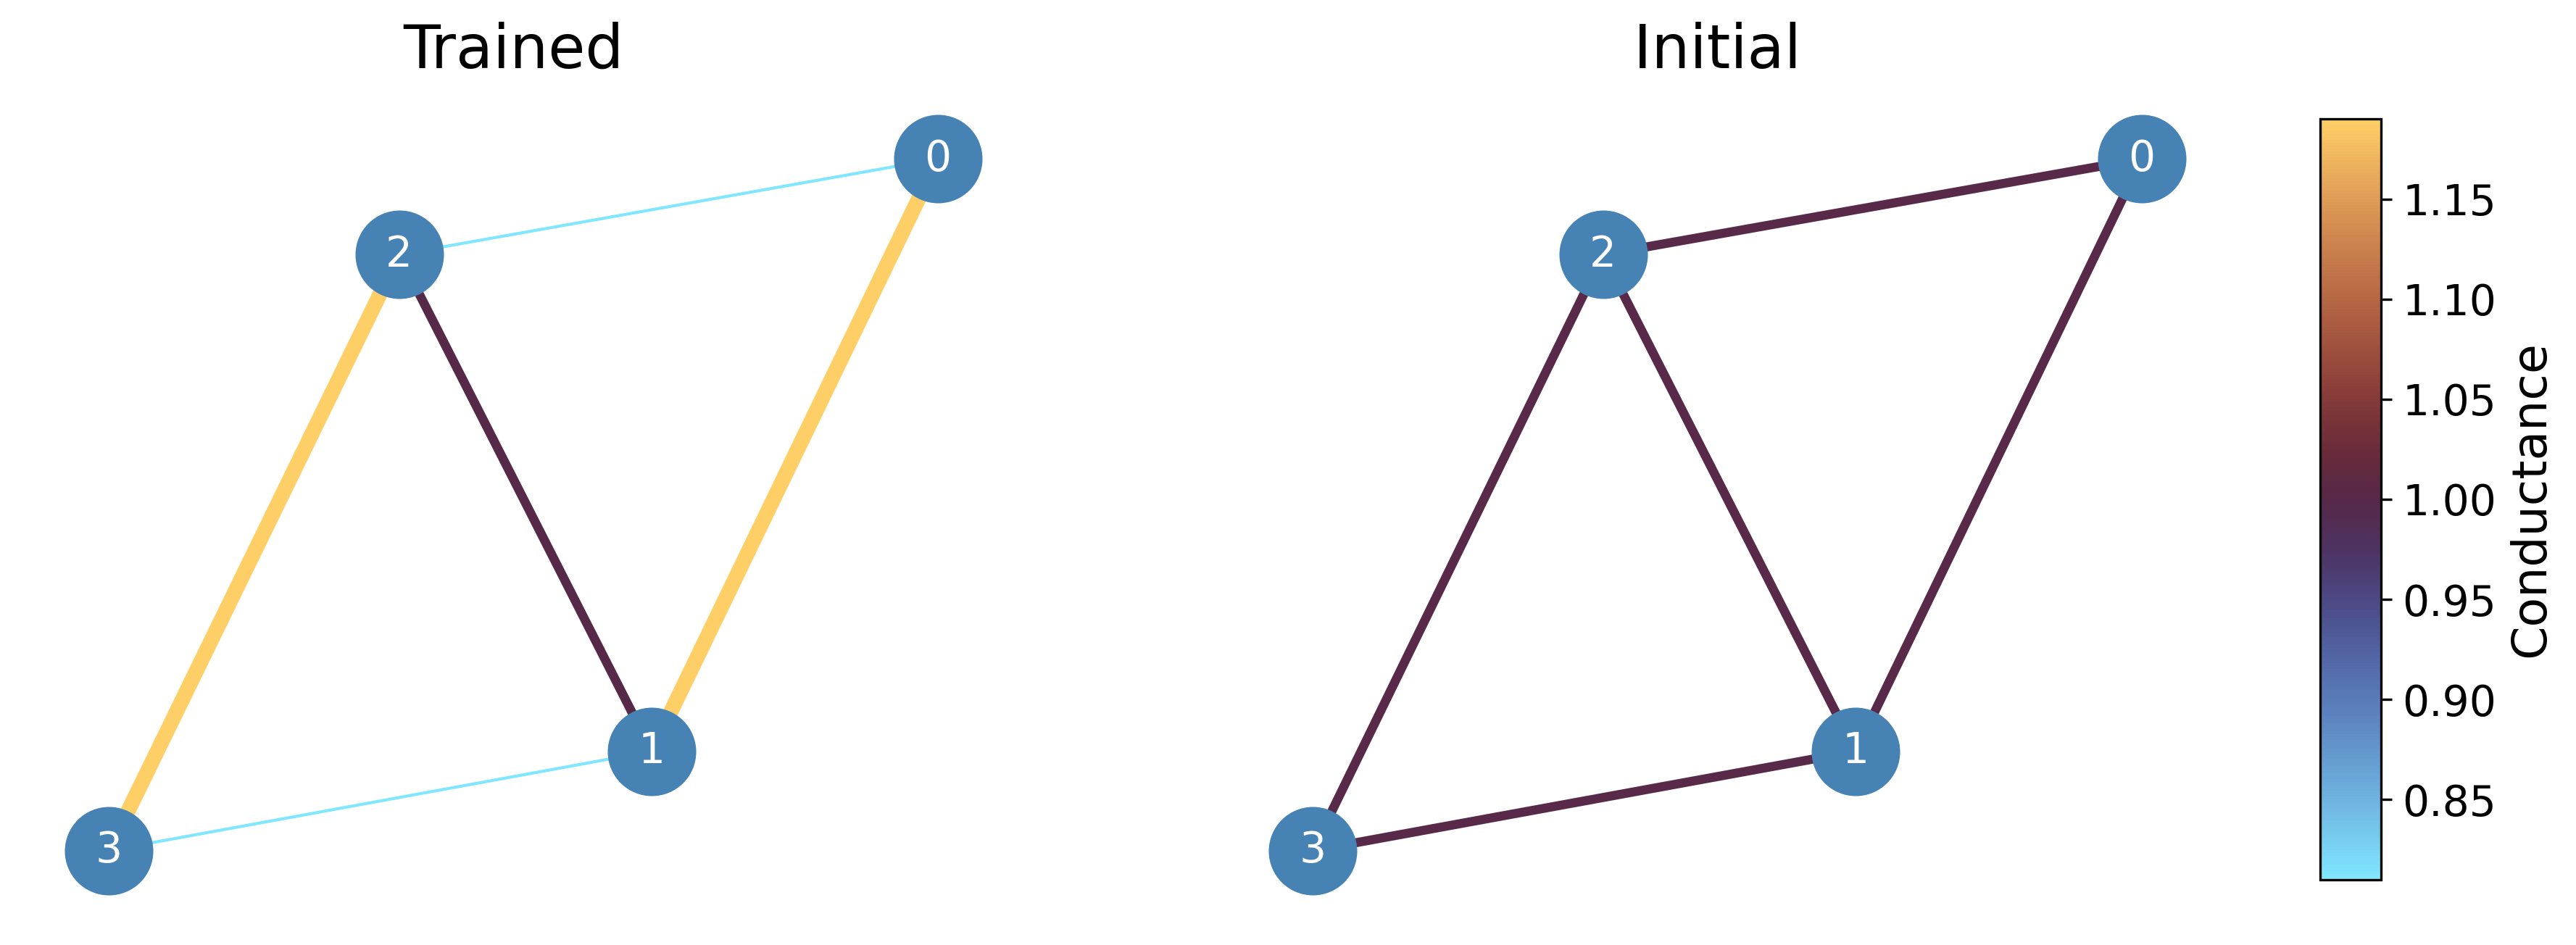

In [ ]:
K_init, L_pinv_init = get_graph_conductances_and_inverse_laplacian(G)

plot_before_after(G_current, G_init, pos,
                  values_before=np.diag(K_curr),
                  values_after=np.diag(K_init),
                  title='', label='Conductance',
                  subtitles=('Trained', 'Initial'),
                  cmap=plt.cm.managua.reversed()) #, log_scale=True)

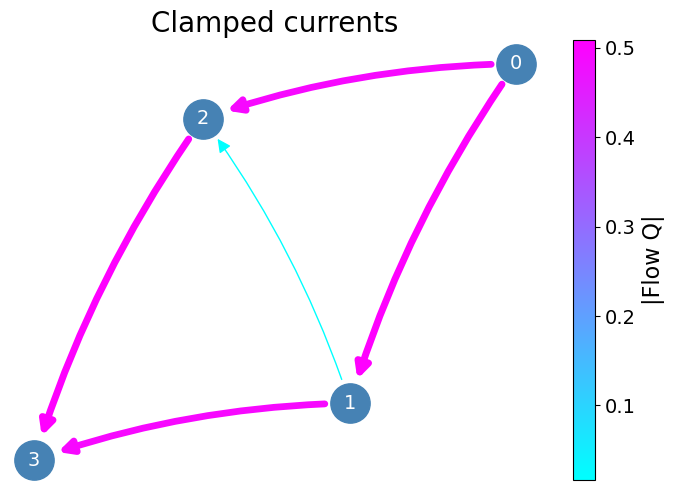

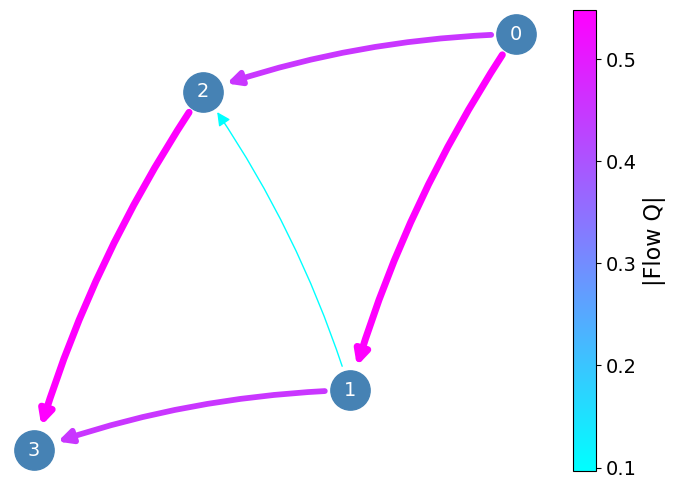

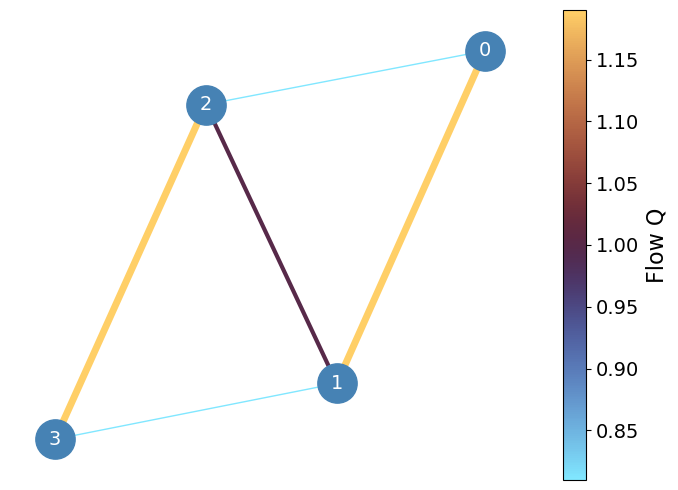

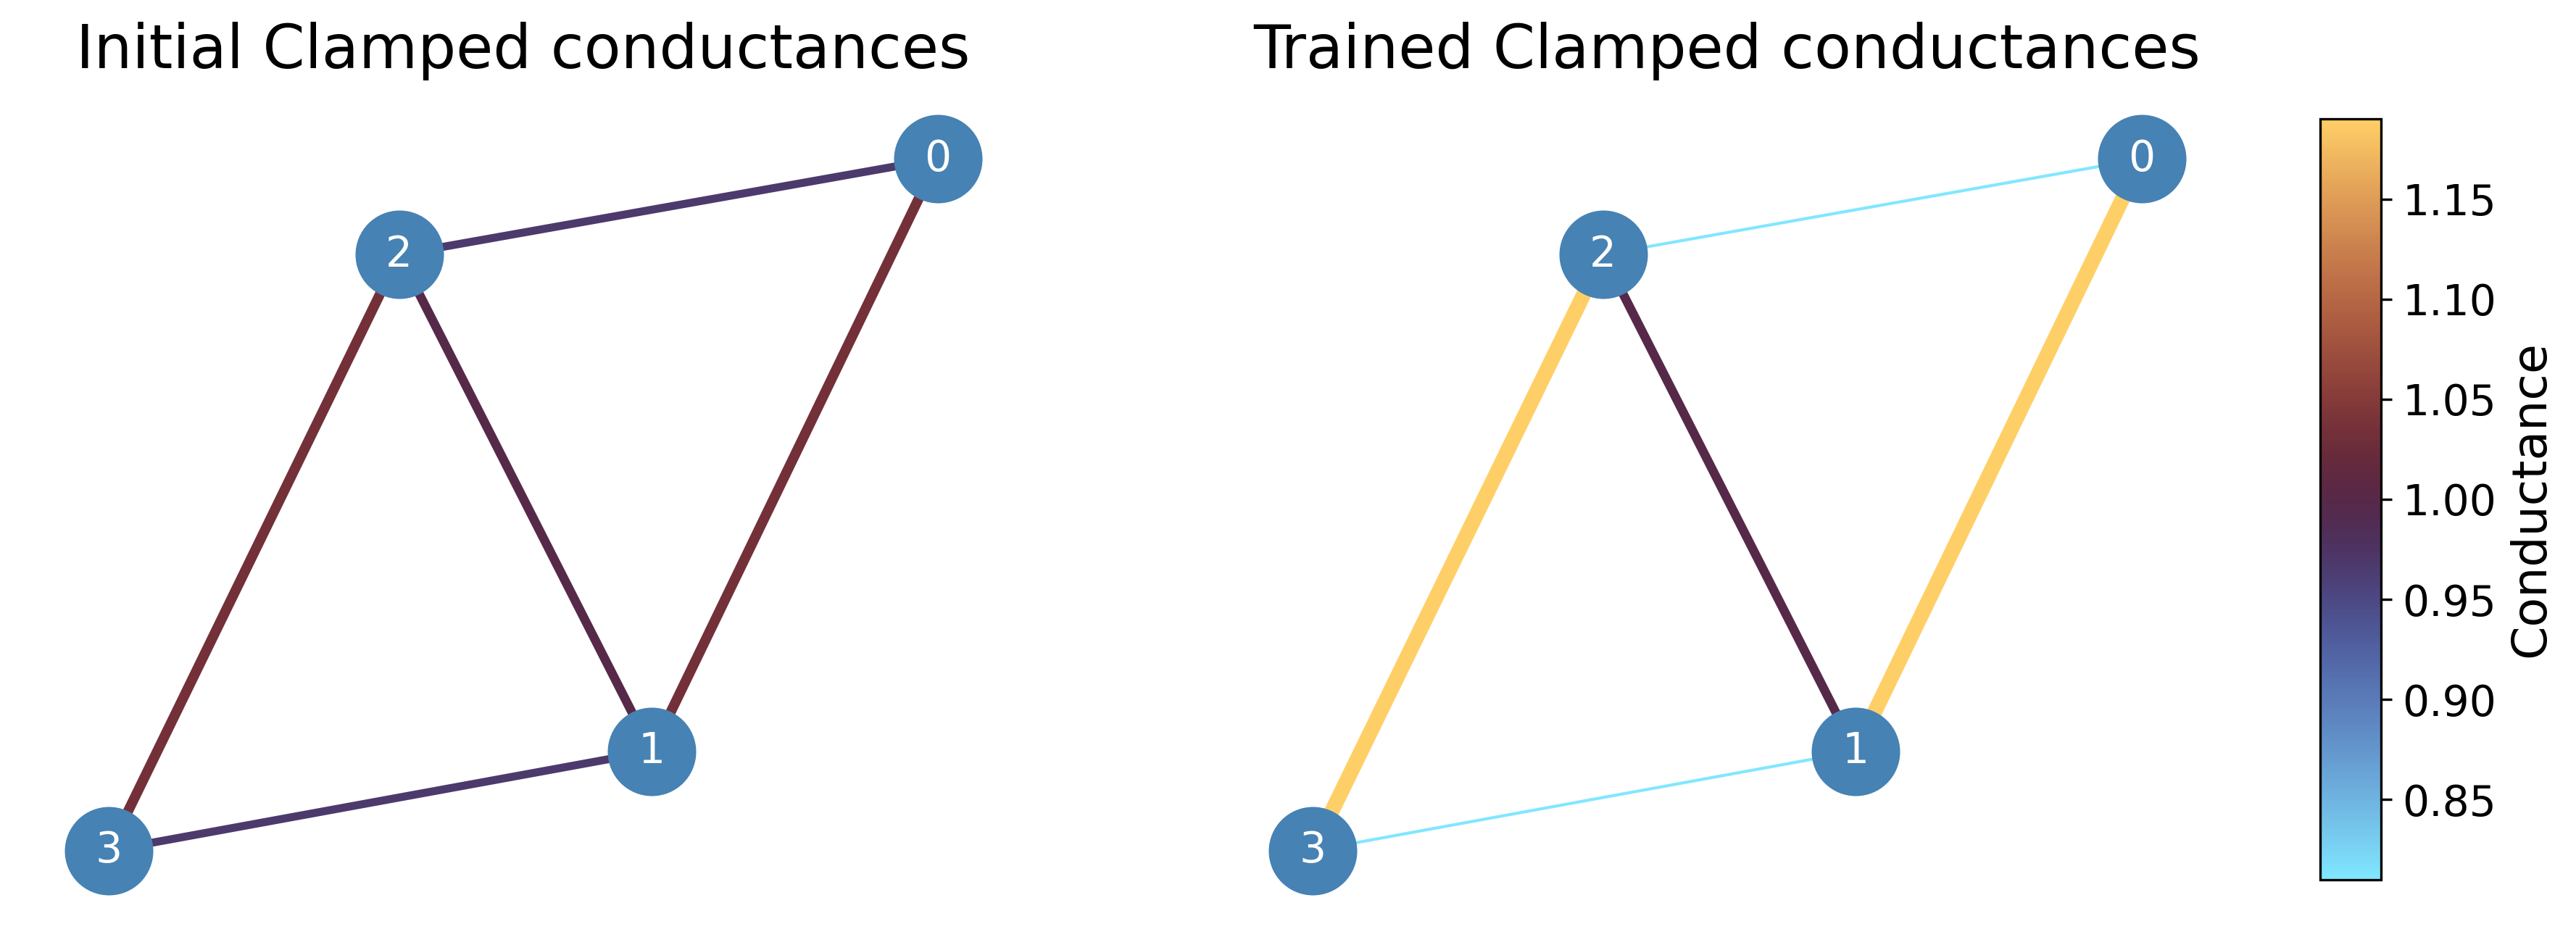

In [ ]:
# visualize how adding some current across the target edge changes the pressures and flows in the clamped phase vs free phase, before any training has happened

# Qin_ex = Qin + 0.26 * (B[:, target_edge_idx])  # inject small current across the target edge`
# p_ex = L_pinv @ Qin_ex
# Q_ex = K @ B.T @ p_ex
plot_edge_property(G, pos, history_flows[15], title='Clamped currents', label='Flow Q', signed=True)

plot_edge_property(G, pos, history_flows[-1], title='', label='Flow Q', signed=True)
plot_edge_property(G, pos, history_conductances[-1], title='', label='Flow Q',cmap=plt.cm.managua.reversed())
plot_before_after(G, G_current, pos, history_conductances[15], history_conductances[-1], title='Clamped conductances', label='Conductance', cmap=plt.cm.managua.reversed())

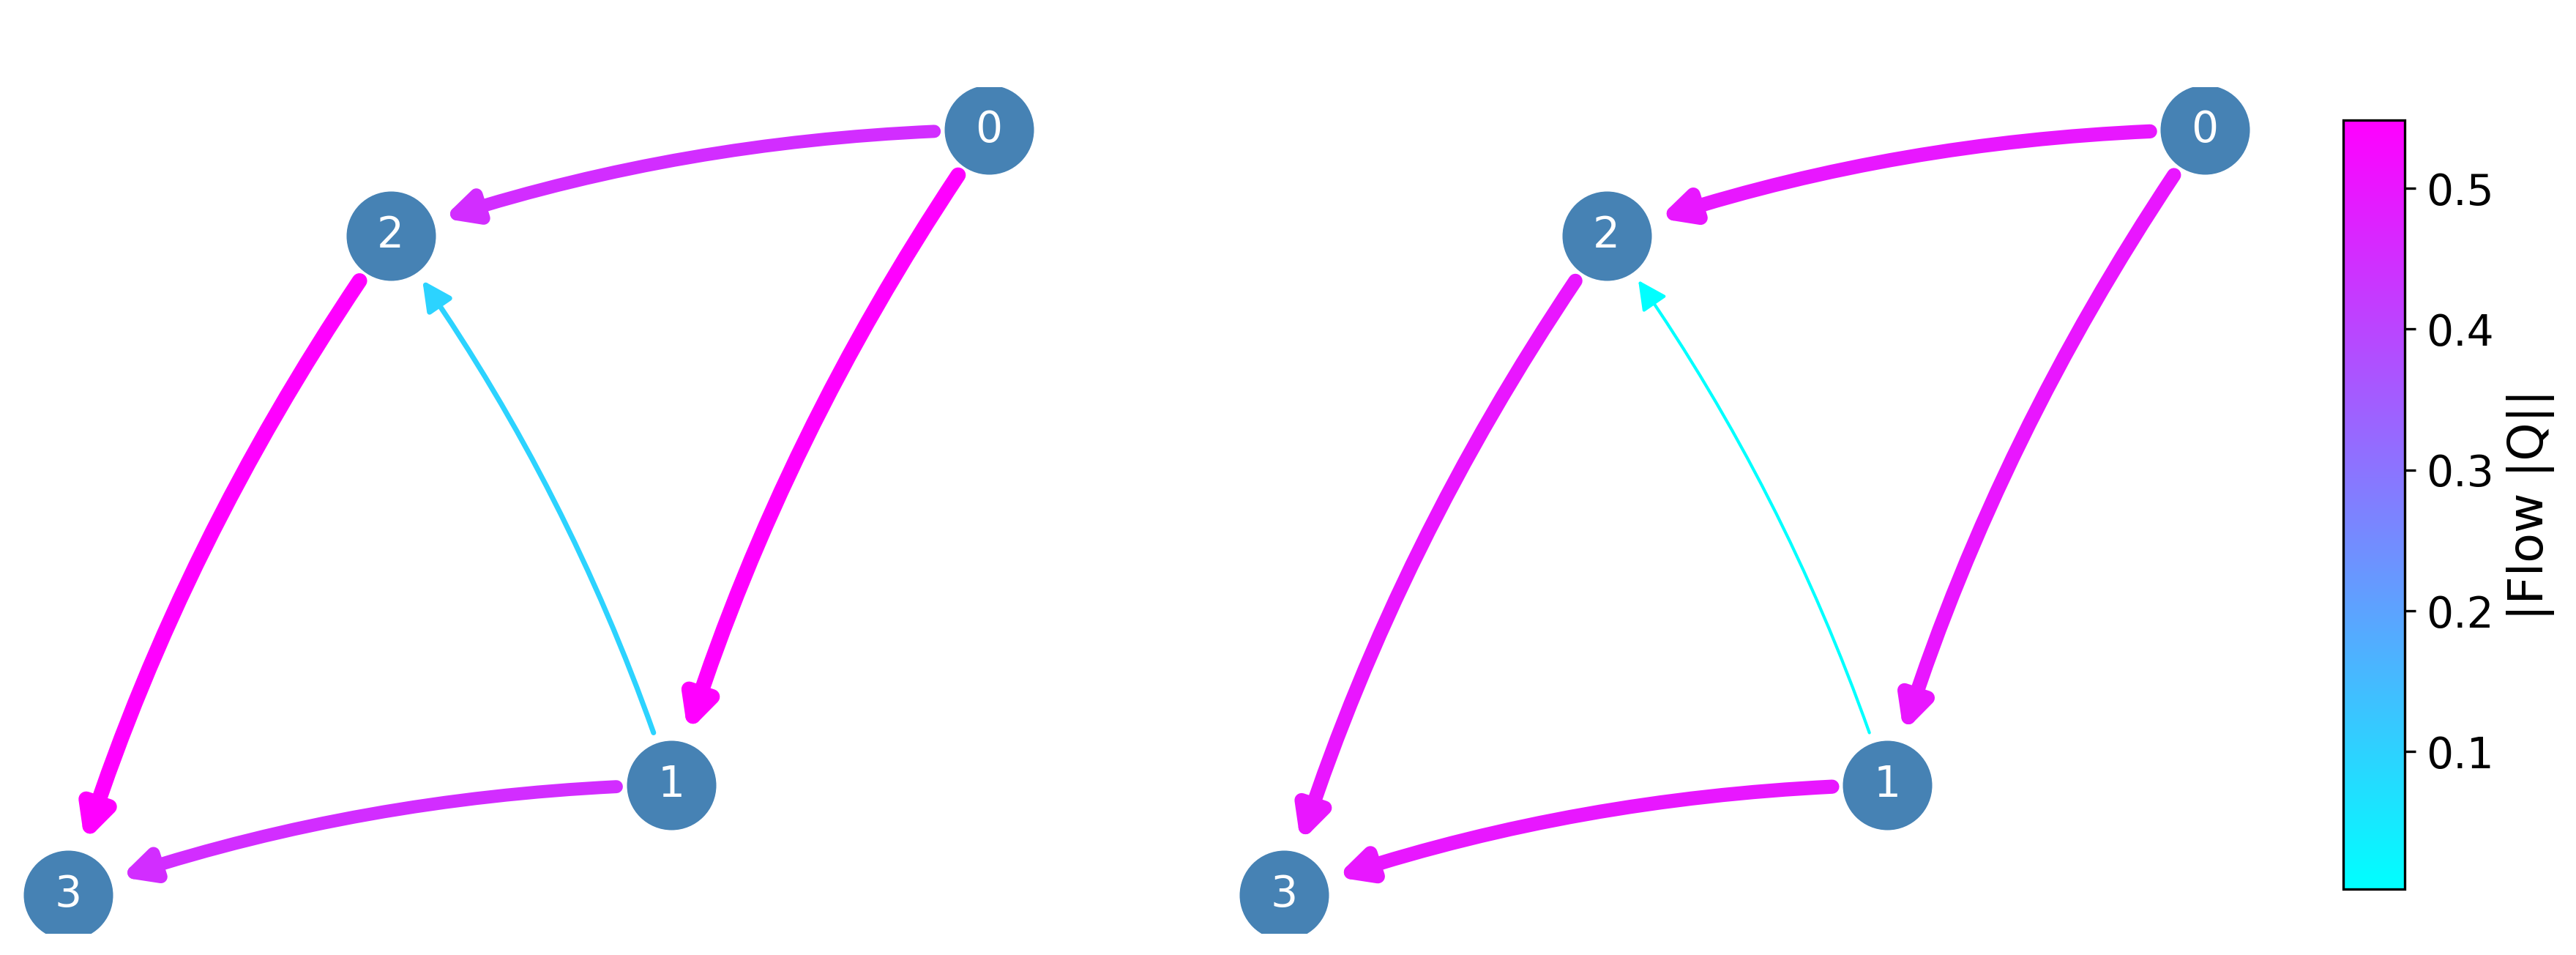

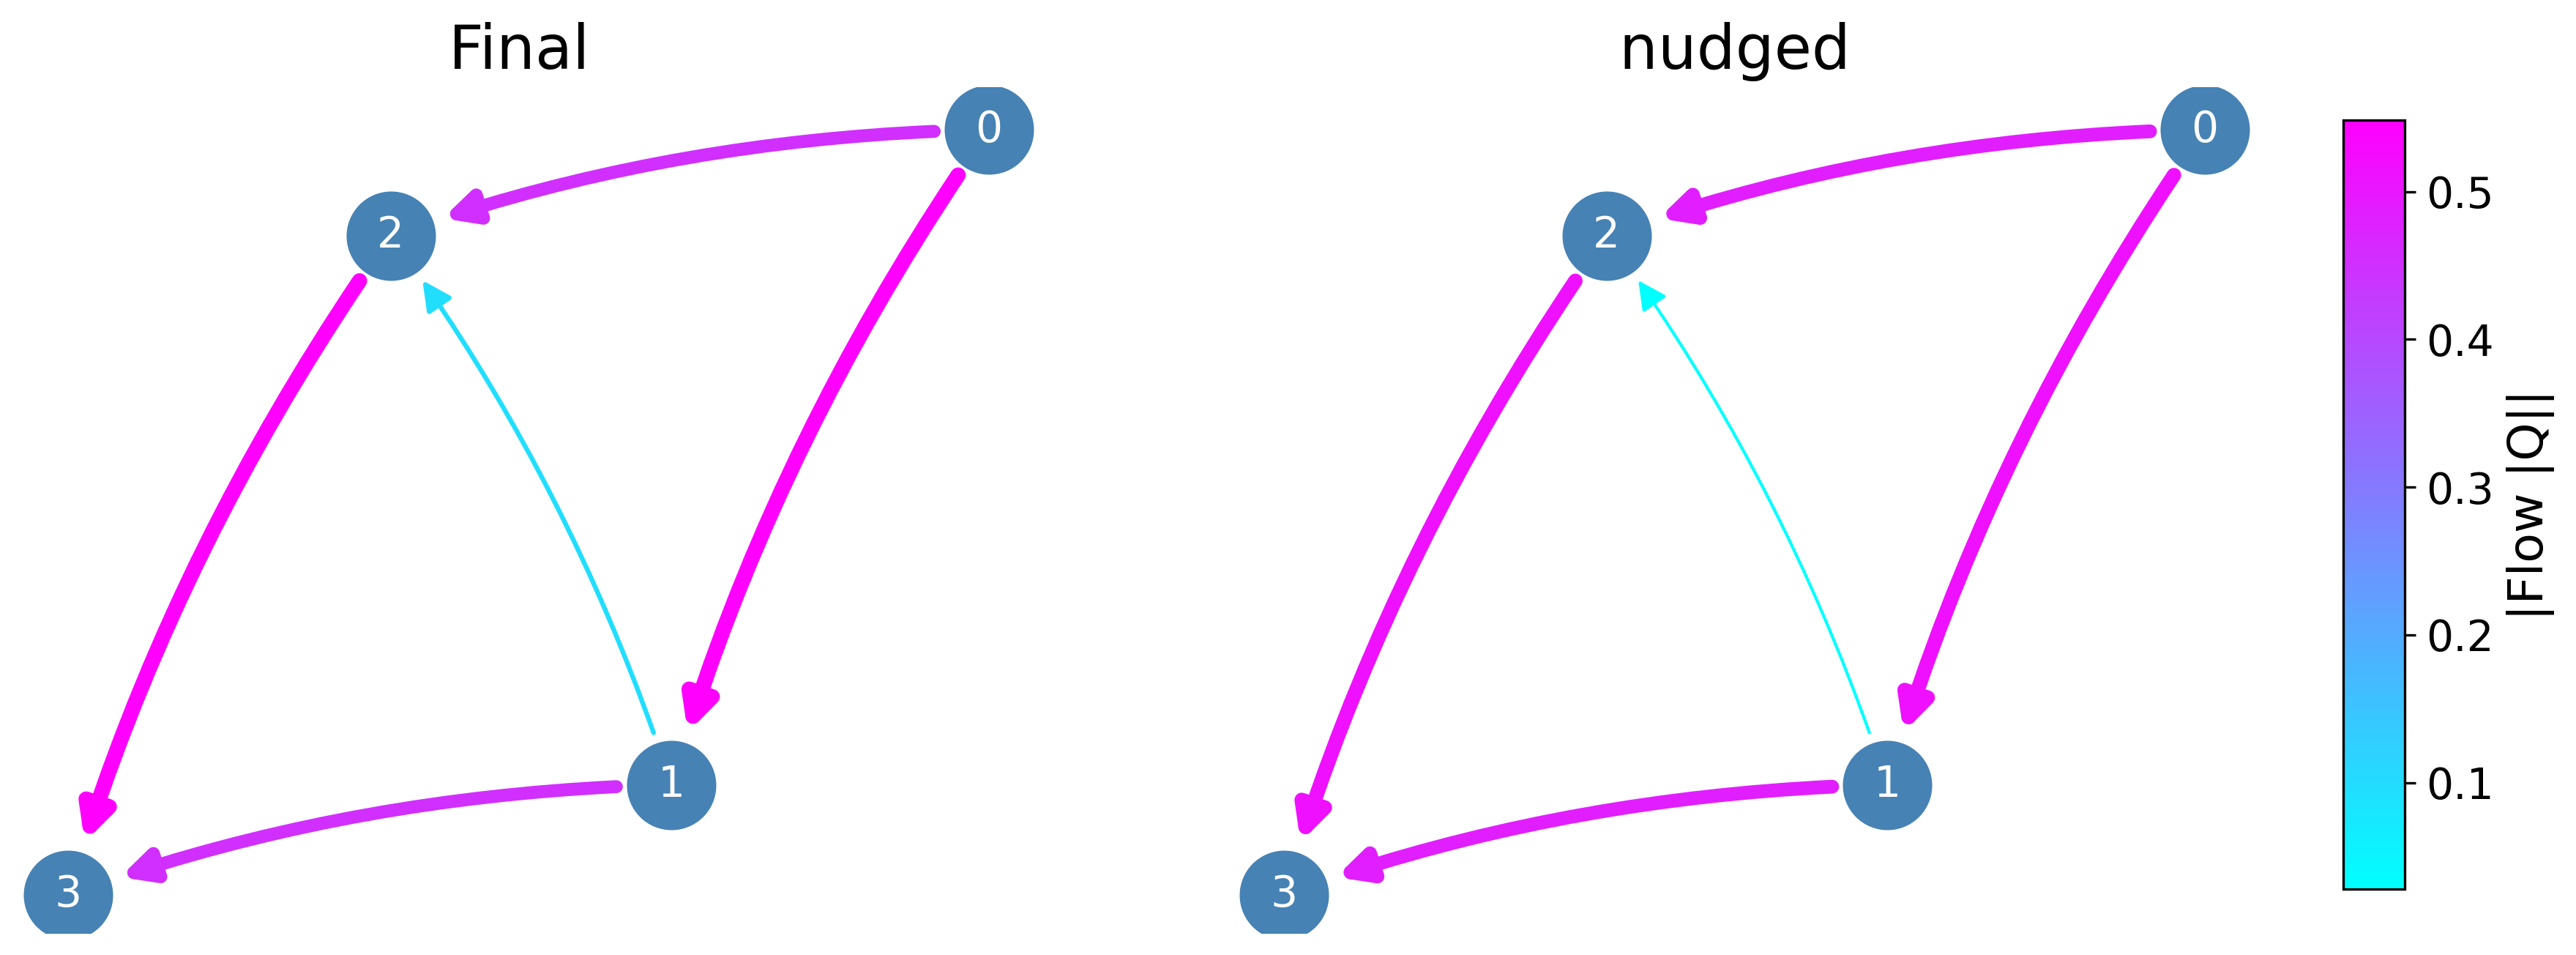

In [ ]:
# Flows — diverging, can be positive or negative
plot_before_after(G_init, G_current, pos,
                  history_flows[-1,:],
                  history_flows[1,:],  # initial flows
                    # final flows
                  title='', label='Flow |Q|',
                  subtitles=('', ''),
                  cmap=plt.cm.cool, signed=True)
plot_before_after(G_init, G_current, pos,
                  history_flows[-1,:],
                  history_flows[30,:],  # initial flows
                    # final flows
                  title='', label='Flow |Q|',
                  subtitles=('Final', 'nudged'),
                  cmap=plt.cm.cool, signed=True)

L(k_ij)*p_c=Q_in
k_ij(p_j-p_i)=Q
Q=k_ij(p_j-p_i)

In [ ]:
history_flows[0,:]
history_flows[-1,:]

array([0.54841844, 0.45158156, 0.09683689, 0.45158156, 0.54841844])

In [ ]:
import matplotlib.ticker as ticker

def plot_training_trajectories(
    history, edges, target_edge_nodes, target_current,
    font_size=18, tick_size=14,
):
    history_steps        = [h['step']         for h in history]
    history_flows        = np.array([h['flows']        for h in history])
    history_conductances = np.array([h['conductances'] for h in history])

    TARGET_COLOR = 'crimson'
    OTHER_COLOR  = '#999999'
    OTHER_ALPHA  = 0.6
    OTHER_LW     = 0.8
    TARGET_LW    = 2.5

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=200)

    for ax, data, ylabel, goal, goal_label in [
        (axes[0], history_conductances, 'Conductance', None,           None),
        (axes[1], history_flows,        'Flow',        target_current, f'goal = {target_current}'),
    ]:
        # background: all other edges
        for i, (u, v) in enumerate(edges):
            if (u, v) != target_edge_nodes:
                ax.plot(history_steps, data[:, i],
                        color=OTHER_COLOR, alpha=OTHER_ALPHA, lw=OTHER_LW, zorder=1, label='other edges' if i == 0 else None)

        # target edge on top
        t_idx = next(i for i, e in enumerate(edges) if e == target_edge_nodes)
        ax.plot(history_steps, data[:, t_idx],
                color=TARGET_COLOR, lw=TARGET_LW, zorder=3, label='target edge')

        if goal is not None:
            ax.axhline(goal, color='k', lw=1.5, ls=':', zorder=2, label=goal_label)

        ax.set_xlabel('Iteration', fontsize=font_size)
        ax.set_ylabel(ylabel,      fontsize=font_size)
        ax.tick_params(axis='both', labelsize=tick_size)
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
        ax.xaxis.get_offset_text().set_fontsize(tick_size)

        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(fontsize=font_size*0.65, frameon=False, loc='upper left')

    plt.tight_layout()
    plt.show()


def plot_loss_trajectory(
    history, font_size=22, tick_size=14, annotations=None, log_scale=False
):
    """
    Slide 2: loss curve with optional annotations.

    Parameters
    ----------
    history     : list of dicts with keys 'step', 'loss'
    annotations : list of dicts with keys 'step', 'text', and optionally 'y_offset'.
                  Example:
                    [{'step': 50,  'text': 'routing clicks'},
                     {'step': 200, 'text': 'plateau breaks'}]
    """
    steps  = [h['step'] for h in history]
    losses = [h['loss'] for h in history]

    fig, ax = plt.subplots(figsize=(7, 4), dpi=200)

    ax.scatter(steps, losses, color='steelblue')
    ax.set_xlabel('Iteration', fontsize=font_size)
    ax.set_ylabel('Loss',      fontsize=font_size)
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))   
    ax.xaxis.get_offset_text().set_fontsize(tick_size)
 
    ax.spines[['top', 'right']].set_visible(False)
    if log_scale:
        ax.set_yscale('log')

    if annotations:
        y_min, y_max = ax.get_ylim()
        y_range      = y_max - y_min
        for ann in annotations:
            s        = ann['step']
            text     = ann['text']
            y_offset = ann.get('y_offset', 0.1 * y_range)
            # find loss value at that step
            idx = min(range(len(steps)), key=lambda i: abs(steps[i] - s))
            y   = losses[idx]
            ax.annotate(
                text,
                xy=(s, y), xytext=(s, y + y_offset),
                arrowprops=dict(arrowstyle='->', color='k', lw=1.2),
                fontsize=12, ha='center',
            )
            ax.axvline(s, color='gray', lw=1, ls='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

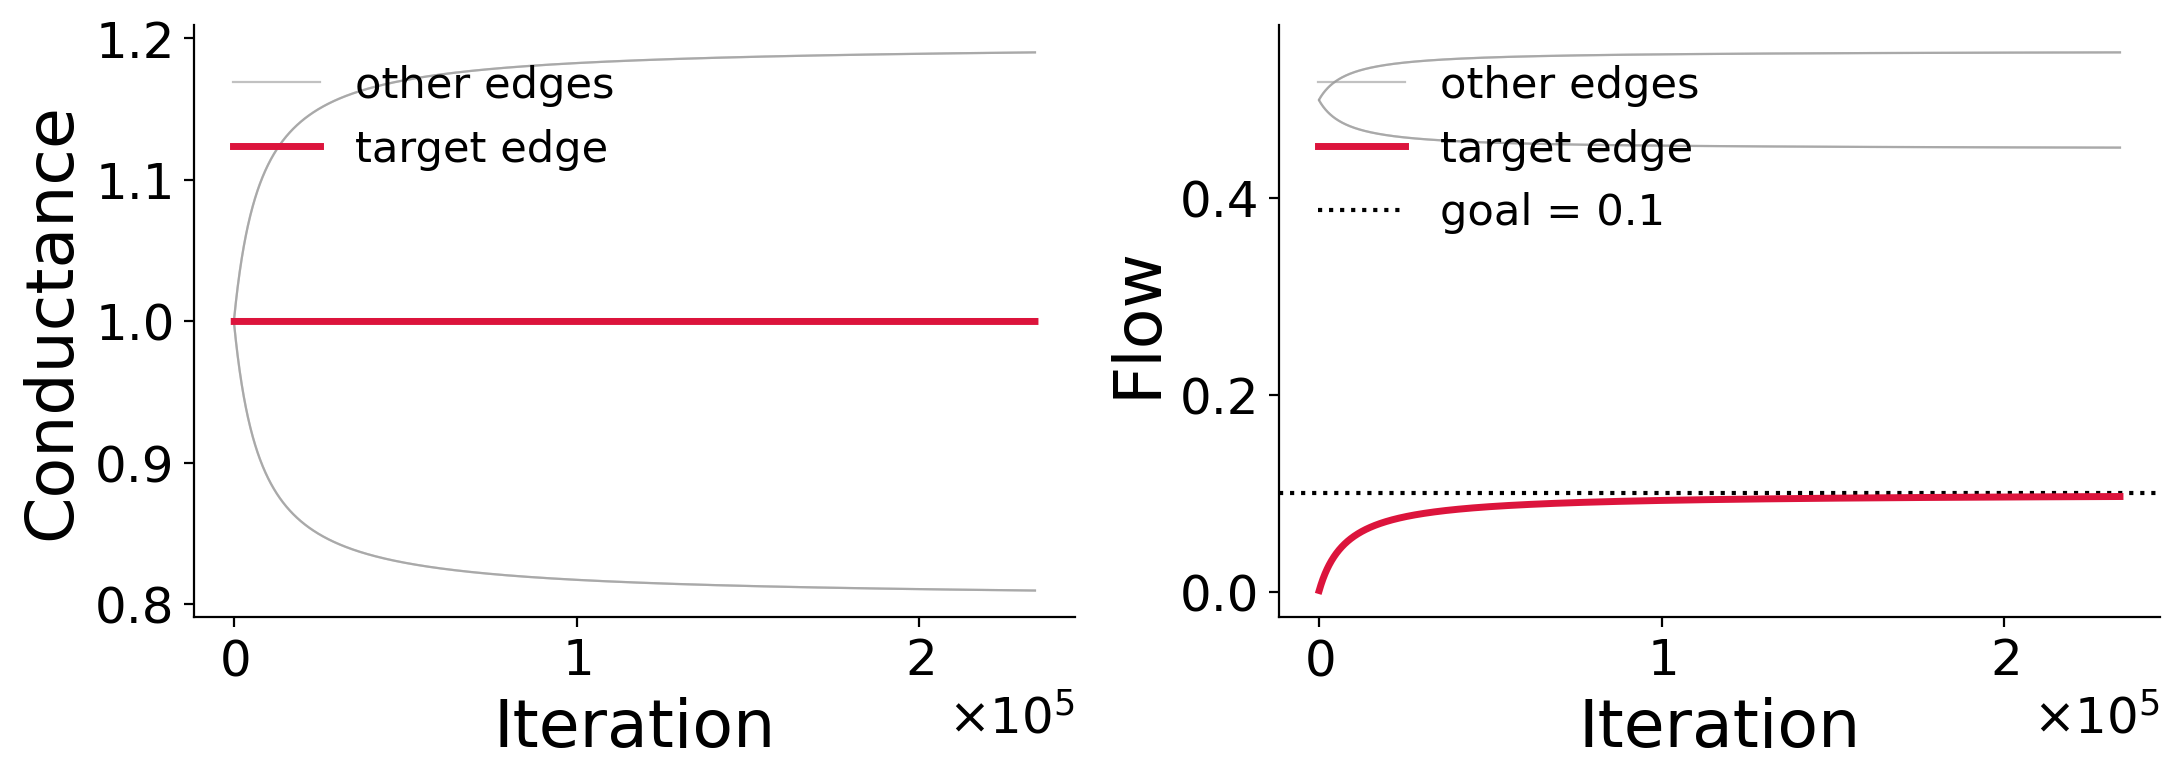

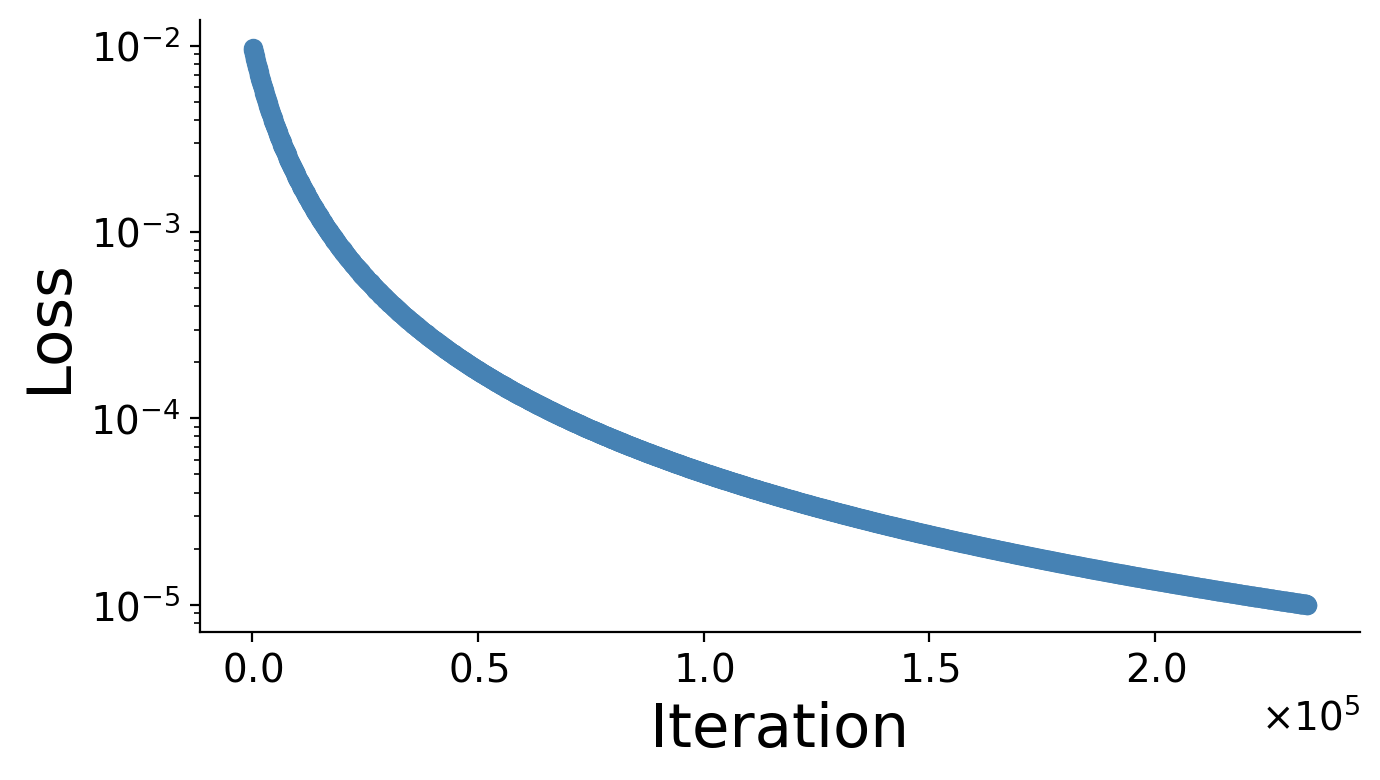

/tmp/ipykernel_52748/660080374.py:100: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


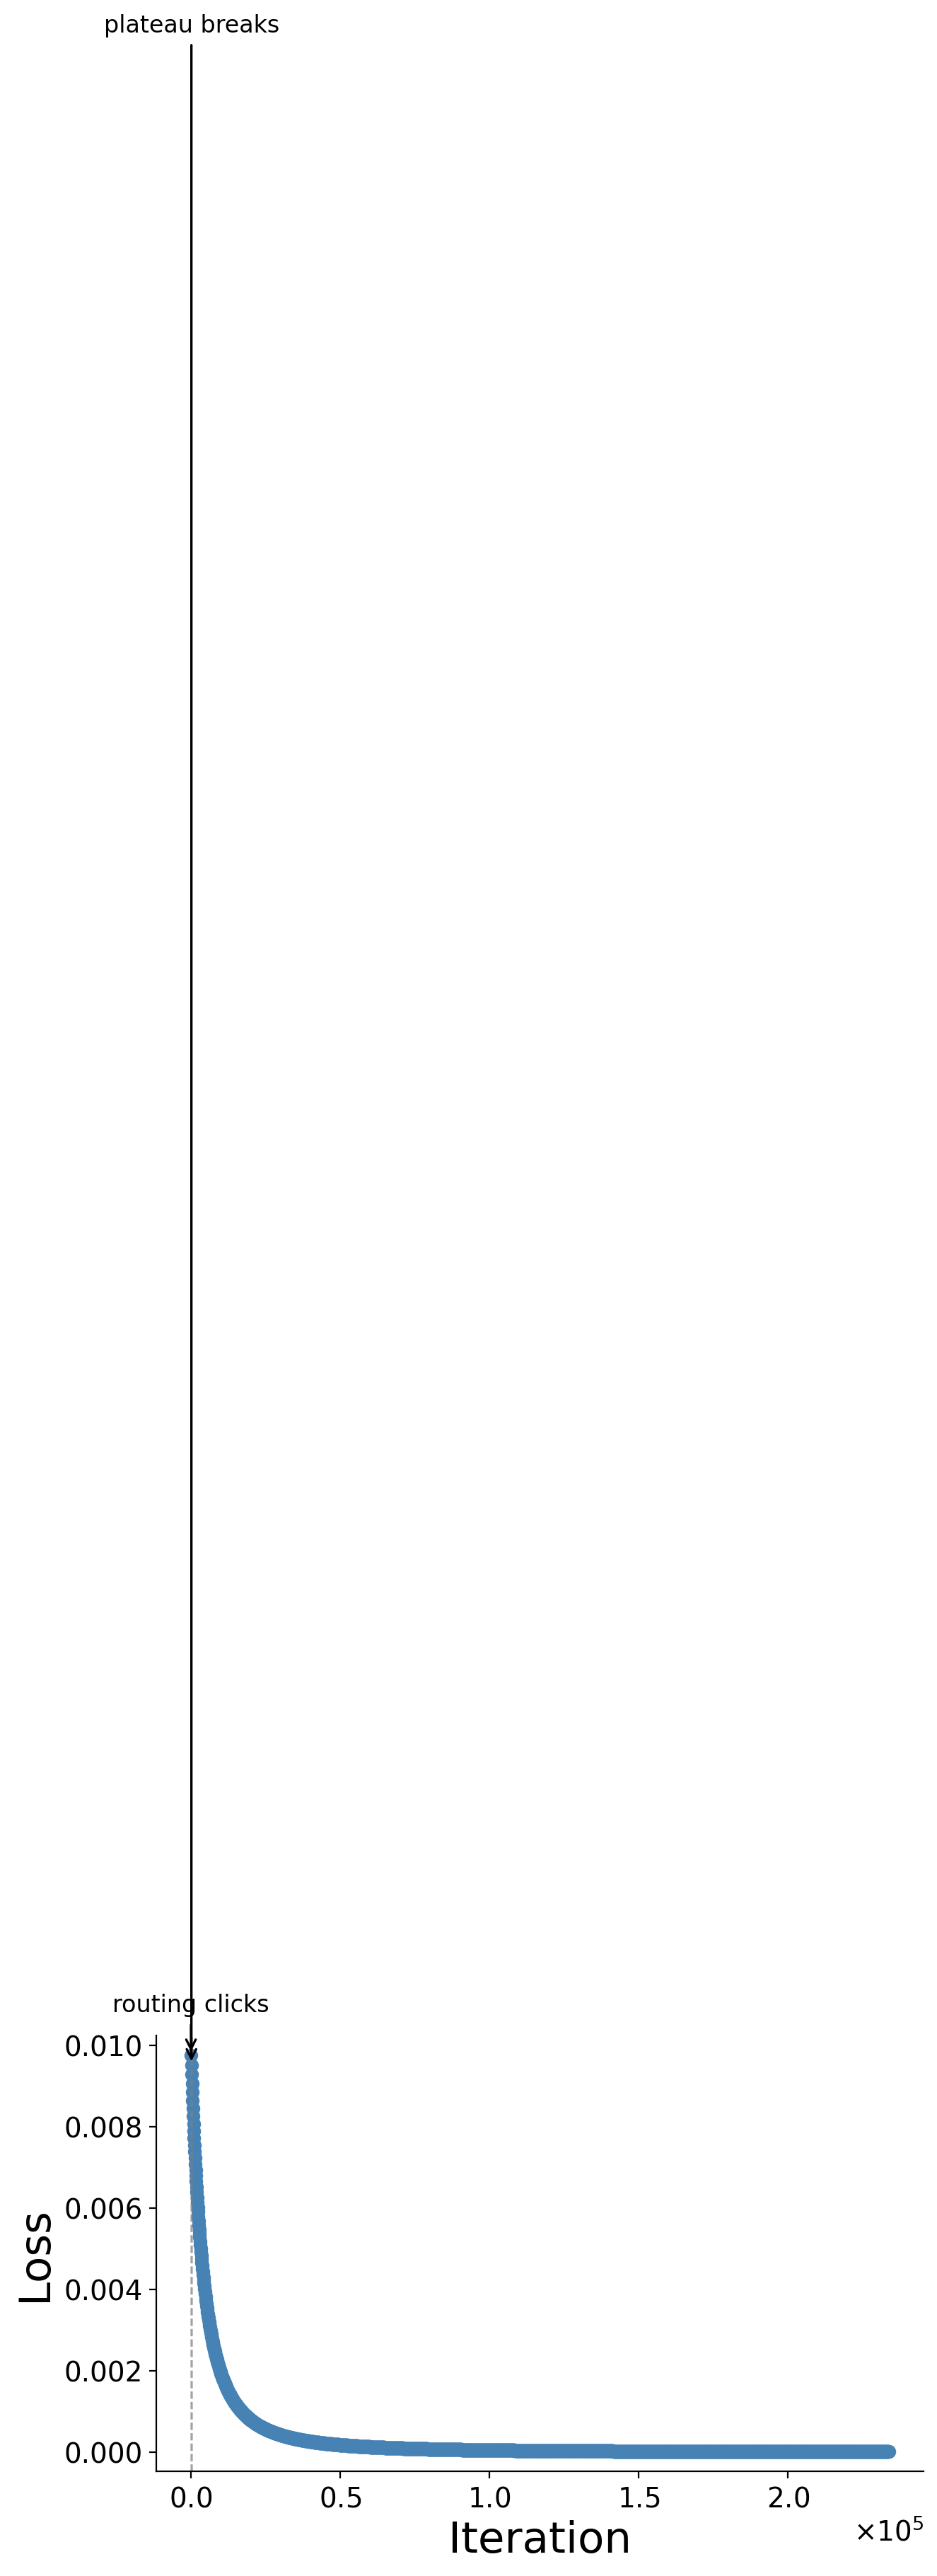

In [ ]:
# Slide 1
plot_training_trajectories(
    history, edges, target_edge_nodes, target_current, font_size=24,tick_size=18
)

# Slide 2 — bare
plot_loss_trajectory(history, font_size=22, log_scale=True)

# Slide 2 — with annotations if the curve has interesting structure
plot_loss_trajectory(history, annotations=[
    {'step': 50,  'text': 'routing clicks'},
    {'step': 200, 'text': 'plateau breaks', 'y_offset': 0.05},
])